In [173]:
import numpy as np
import matplotlib.pyplot as plt 
import json
import polars as pl
from typing import List, Tuple, Dict, Any

from dnnlib.util import EasyDictNested
from mylib.diffusion import time_steps_edm

def load_json_data(filepath: str) -> List[Dict]:
    """Load and parse JSON data from runs file."""
    with open(filepath, 'r') as file:
        content = file.read()
    
    # Split the content into individual JSON strings
    json_strings = content.strip().split('\n}\n')
    
    # Add the missing closing brace to each split string (except the last one)
    json_objects = []
    for i, s in enumerate(json_strings):
        if i < len(json_strings) - 1:
            s += '}'  # Add the closing brace that was split off
        json_objects.append(json.loads(s))
    
    return json_objects

def create_metrics_df():
    json_objects = load_json_data("data/runs.json")
    df = (pl.DataFrame(json_objects)).select([
        "run_id",
        "num_images",
        pl.col("sampler").struct["apply_2nd_order"],
        pl.col("sampler").struct["num_steps"],
        pl.col("sampler").struct["S_churn"],
        pl.col("generate").struct["example_idx_range"],
        pl.col("gvf").struct["vectorfield"].struct["noise_gate"],
        pl.col("metrics")
    ]).unnest("noise_gate")

    return df
    
def print_formatted_table(df: pl.DataFrame):
    """Print dataframe as formatted LaTeX-style table."""
    formatted_rows = []
    for row in df.iter_rows():
        formatted_rows.append("&" + "\t&".join((str(x) for x in row)) + " \\\\")
    
    print("\n".join(formatted_rows))

def substract_baseline(df: pl.DataFrame, df_base: pl.DataFrame):
    assert dfs["base"].shape[0] == 1,\
    f"Expected baseline dataframe to have shape : (1, {df.shape[1]})  , got shape : {df_base.shape}"   
    df = df.with_columns([
        df[col] - df_base[col].item()
        for col in df.columns
        if col != "nu"
    ])
    
    return df
    
def plot_metric(
    df: pl.DataFrame, 
    ax: plt.Axes,
    metrics: List[str],
    df_base : pl.DataFrame = None,
):

    # If baseline dataframe, display difference
    if df_base is not None:
        df = substract_baseline(df, df_base)

    # Plot (nu, metric) for each specified metric
    x = df["nu"]
    for metric in metrics:
        ax.scatter(x, df[metric], label= metric)

    # Stylize axis
    ax.set_axisbelow(True)
    ax.axhline(y=0, c="black", ls="--", alpha=0.5, zorder=1)
    ax.grid(True)
    ax.legend(loc="best")
    ax.set_xscale('log')


# Import all runs and baseline

In [174]:
df_all = create_metrics_df()
dfs = {}
dfs["base"] = df_all.filter([
    # 2nd Order Sampling 
    pl.col("apply_2nd_order")   == True,
    pl.col("num_steps")         == 32,
    # Num steps = 10_000
    pl.col("num_images")        == 10_000,
    # No noise gate
    pl.col("type_gate").is_null(),
    pl.col("nu").is_null(),
    # Many-Examples
    pl.col("example_idx_range").is_null(),
    # Deterministic
    pl.col("S_churn")           == 0, 
]).select(["nu", "metrics"]).unnest("metrics")


# Many-Example Determinstic 2nd-Order

In [175]:
df = df_all.filter([
    # 2nd Order Sampling 
    pl.col("apply_2nd_order")   == True,
    pl.col("num_steps")         == 32,
    # Heaviside noise gate
    pl.col("type_gate")         == "heaviside",
    # No delayed guidance initialization
    pl.col("noise_onset")       == 80.0,
    # Many-Examples
    pl.col("example_idx_range").is_null(),
    # Deterministic
    pl.col("S_churn")           == 0,
]).select(["nu", "metrics"]).sort("nu")


dfs[0] = df.unnest("metrics")

# Ensure you have no duplicates of nu 
assert dfs[0]["nu"].is_unique().all() == True

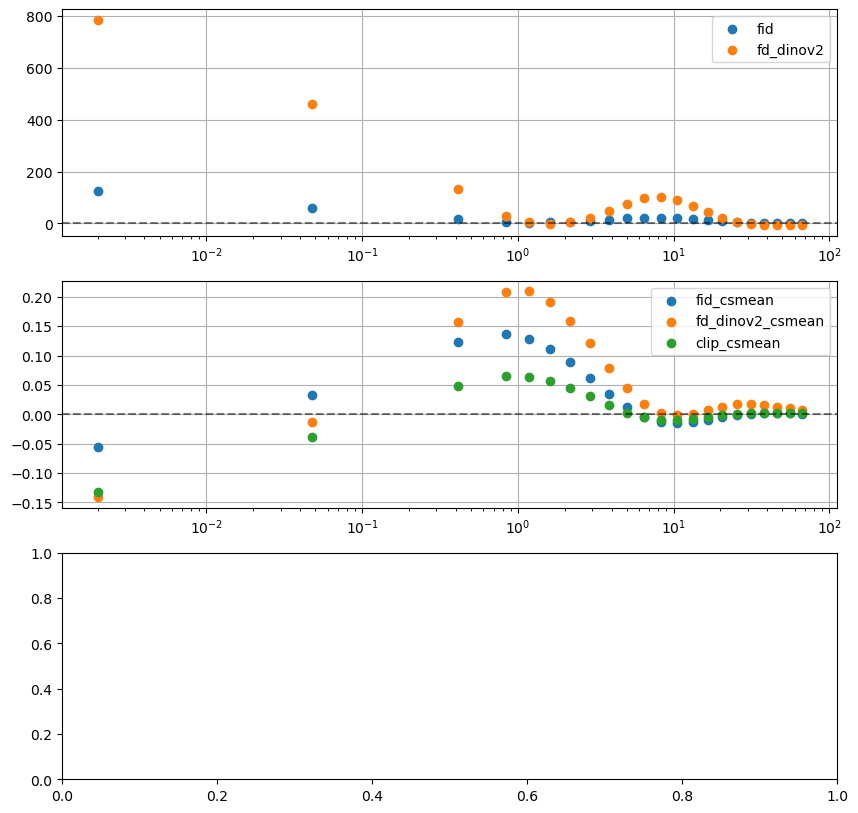

In [181]:
fig, axes = plt.subplots(3, figsize=(10, 10))

df = dfs[0]
plot_metric(df, axes[0], metrics=["fid", "fd_dinov2"], df_base=dfs["base"])
plot_metric(df, axes[1], metrics=["fid_csmean", "fd_dinov2_csmean", "clip_csmean"], df_base=dfs["base"])




In [177]:
dfs["base"]

nu,fid,fd_dinov2,fid_csmean,fd_dinov2_csmean,clip_csmean,L2_mean
f64,f64,f64,f64,f64,f64,f64
null,5.098343,145.359819,0.656302,0.341186,0.770874,null
